# Bike Sharing Demand Forecasting

## Problem Description

The goal of this notebook is to predict the number of bike rentals in the next hour
given a sequence of past hourly observations. This is a **univariate regression** problem
framed as a **time series forecasting** task.

The dataset comes from the [Bike Sharing Demand](https://openml.org/search?type=data&status=active&id=44063)
dataset, originally from the UCI Machine Learning Repository. It contains hourly rental
counts from a bike sharing system in Washington D.C. between 2011 and 2012, along with
contextual features such as weather conditions, time of day, and season.

**Prediction target:** number of bike rentals at hour `t+1`  
**Input:** sequence of 24 consecutive hourly observations up to hour `t`  
**Metric:** Mean Absolute Error (MAE) in bikes/hour

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import openml
import os

In [ ]:
dataset = openml.datasets.get_dataset(44063) 
X, y,cat,names = dataset.get_data(dataset_format = 'dataframe', target = dataset.default_target_attribute)

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.dtypes)
print("\nTarget (first 5):")
print(y.head())
print("\nNulls:")
print(X.isnull().sum())

X shape: (17379, 11)
y shape: (17379,)

Features:
season        category
year          category
month            uint8
hour             uint8
holiday       category
workingday    category
weather       category
temp           float64
feel_temp      float64
humidity       float64
windspeed      float64
dtype: object

Target (first 5):
0    16
1    40
2    32
3    13
4     1
Name: count, dtype: int64

Nulls:
season        0
year          0
month         0
hour          0
holiday       0
workingday    0
weather       0
temp          0
feel_temp     0
humidity      0
windspeed     0
dtype: int64


# Dataset Exploration

The dataset contains **17,379 hourly records** with the following features:

| Feature | Type | Description |
|---|---|---|
| `temp` | float | Normalized temperature (°C) |
| `feel_temp` | float | Normalized feeling temperature (°C) |
| `humidity` | float | Normalized humidity |
| `windspeed` | float | Normalized wind speed |
| `hour` | int | Hour of the day (0–23) |
| `month` | int | Month of the year (1–12) |
| `season` | category | Spring, Summer, Fall, Winter |
| `year` | category | 2011 or 2012 |
| `holiday` | category | Whether the day is a holiday |
| `workingday` | category | Whether the day is a working day |
| `weather` | category | Weather situation (1=clear, 4=heavy rain) |
| `count` | int | **Target**: number of bike rentals |

Key observations from the data:
- Demand shows strong **daily periodicity** (peaks during commute hours)
- Demand shows strong **weekly periodicity** (weekdays vs weekends)
- Demand is heavily influenced by **weather** and **season**
- The series is **non-stationary** — 2012 shows higher demand than 2011 overall

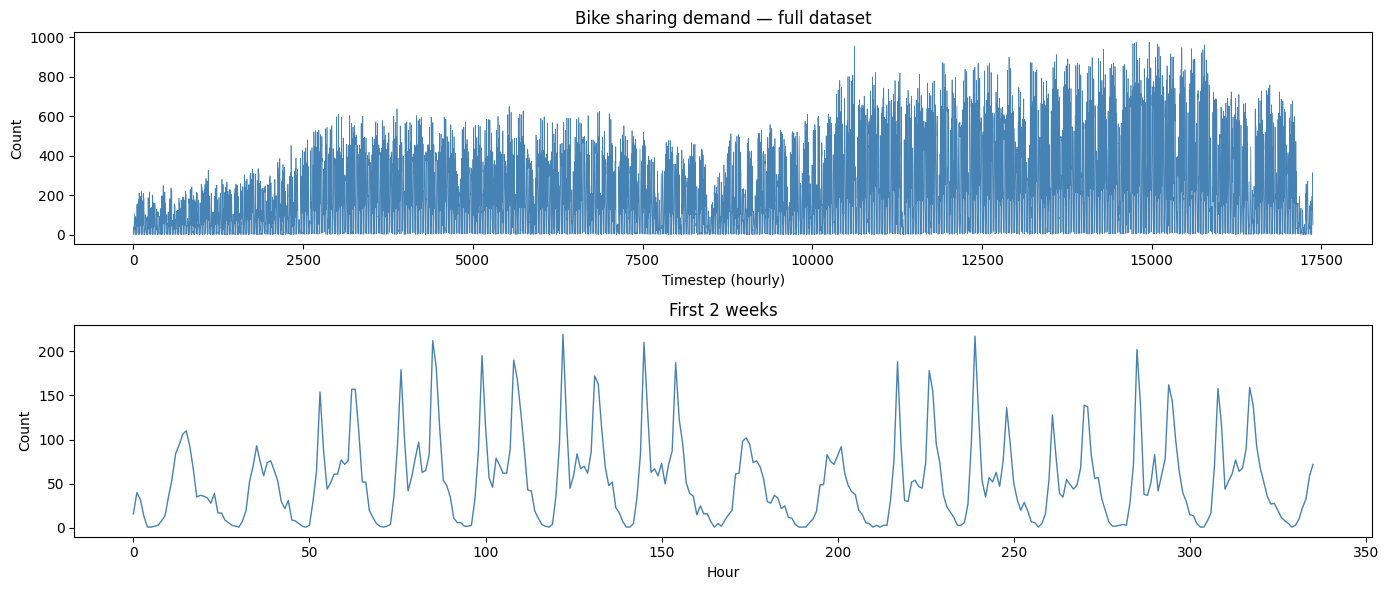

In [ ]:
fig, axes = plt.subplots(2, 1, figsize = (14, 6))

axes[0].plot(y.values, linewidth = 0.5, color = "steelblue")
axes[0].set_title("Bike sharing demand — full dataset")
axes[0].set_xlabel("Timestep (hourly)")
axes[0].set_ylabel("Count")

axes[1].plot(y.values[:24*14], linewidth = 1.0, color = "steelblue")
axes[1].set_title("First 2 weeks")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Feature Engineering

Three types of feature transformations are applied before training:

### 1. Cyclical encoding for `hour` and `month`
Time features like hour and month are **circular** — hour 23 and hour 0 are adjacent,
not maximally distant. Treating them as integers would mislead the model.
We encode them as sine/cosine pairs:

$$\text{hour\_sin} = \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right), \quad
\text{hour\_cos} = \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

This preserves the circular structure in a continuous, differentiable representation.

### 2. One-hot encoding for categorical features
Categorical features (`season`, `year`, `holiday`, `workingday`, `weather`) are
one-hot encoded so the model treats each category independently without imposing
an artificial ordinal relationship.

Yes — we kept the rolling stats, so update it to:
markdown

### 3. Lagged features strategy

Unlike tree-based models (which require explicit feature engineering),
**RNNs learn temporal dependencies automatically** from the sequence structure.
However, not all lagged features are redundant with the sequence window:

**Excluded from RNN input — simple lag counts:**
`lagged_count_1h`, `lagged_count_2h`, `lagged_count_3h`, `lagged_count_1d`, etc.
These are redundant — the RNN already sees the raw count at each timestep
of the 24-hour input window, so explicitly providing `count_{t-1}` adds no new information.

**Kept for RNN input — rolling statistics:**
`lagged_mean_24h`, `lagged_max_24h`, `lagged_min_24h`, `lagged_mean_7d`, `lagged_max_7d`, `lagged_min_7d`
These are **not redundant** — they summarize demand patterns over windows of
24 hours and 7 days, which extend well beyond the 24-step sequence the RNN sees.
They give the model long-range context it could not otherwise access.

> **Summary:** simple lags → redundant → excluded. Rolling stats → long-range context → 

In [ ]:
df = X.copy()
df["count"] = y.values

# --- Cyclical encoding for hour and month ---
# hour and month are circular: hour 23 and hour 0 are adjacent, not distant
# sin/cos pairs preserve this circular structure
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df = df.drop(columns = ["hour", "month"])

# --- One-hot encode categoricals ---
df = pd.get_dummies(df, columns = ["season", "year", "holiday", "workingday", "weather"])

# --- Simple lagged counts (used for sklearn baseline and naive baseline) ---
df["lagged_count_1h"] = df["count"].shift(1)
df["lagged_count_2h"] = df["count"].shift(2)
df["lagged_count_3h"] = df["count"].shift(3)
df["lagged_count_1d"] = df["count"].shift(24)
df["lagged_count_1d_1h"] = df["count"].shift(25)
df["lagged_count_7d"] = df["count"].shift(7 * 24)
df["lagged_count_7d_1h"] = df["count"].shift(7 * 24 + 1)

# --- Rolling stats (kept for RNN — provide long-range context beyond 24h window) ---
# shift(1) before rolling to avoid leaking the current timestep into the stat
df["lagged_mean_24h"] = df["count"].shift(1).rolling(24).mean()
df["lagged_max_24h"] = df["count"].shift(1).rolling(24).max()
df["lagged_min_24h"] = df["count"].shift(1).rolling(24).min()
df["lagged_mean_7d"] = df["count"].shift(1).rolling(7 * 24).mean()
df["lagged_max_7d"] = df["count"].shift(1).rolling(7 * 24).max()
df["lagged_min_7d"] = df["count"].shift(1).rolling(7 * 24).min()

# --- Drop NaN rows introduced by lagging (first 7*24=168 rows) ---
df = df.dropna().reset_index(drop = True)

print(f"Shape after feature engineering: {df.shape}")
print(f"Columns ({len(df.columns)}):")
for col in df.columns:
    print(f"  {col}")

Shape after feature engineering: (17210, 36)
Columns (36):
  temp
  feel_temp
  humidity
  windspeed
  count
  hour_sin
  hour_cos
  month_sin
  month_cos
  season_0
  season_1
  season_2
  season_3
  year_0
  year_1
  holiday_0
  holiday_1
  workingday_0
  workingday_1
  weather_0
  weather_1
  weather_2
  weather_3
  lagged_count_1h
  lagged_count_2h
  lagged_count_3h
  lagged_count_1d
  lagged_count_1d_1h
  lagged_count_7d
  lagged_count_7d_1h
  lagged_mean_24h
  lagged_max_24h
  lagged_min_24h
  lagged_mean_7d
  lagged_max_7d
  lagged_min_7d


# Train / Validation / Test Split

The dataset is split **chronologically** — no shuffling. This is mandatory for
time series: the model must be trained on the past and evaluated on the future,
never the reverse.

| Split | Size | Purpose |
|---|---|---|
| Train | 70% (~12,000 hours) | Model training |
| Validation | 15% (~2,500 hours) | Hyperparameter tuning, early stopping |
| Test | 15% (~2,500 hours) | Final unbiased evaluation |

> **Why not use `train_test_split` with `shuffle=True`?**
> Shuffling would allow the model to train on data from the future and evaluate
> on the past — artificially inflating performance. Always use temporal ordering
> for time series evaluation.

In [ ]:
n = len(df)
num_train = int(0.70 * n)
num_val = int(0.15 * n)
num_test = n - num_train - num_val

train_df = df.iloc[:num_train]
val_df = df.iloc[num_train:num_train + num_val]
test_df = df.iloc[num_train + num_val:]

print(f"\nTrain: {num_train} | Val: {num_val} | Test: {num_test}")


Train: 12047 | Val: 2581 | Test: 2582


## Commonsense Baseline

Before training any model, we establish a **naive baseline** — the simplest
possible prediction strategy. Its purpose is to set a minimum performance
threshold that any learned model must exceed to justify its complexity.

**Strategy:** predict that demand at hour `t+1` equals demand at hour `t`:

$$\hat{y}_{t+1} = y_t$$

This is a reasonable heuristic since bike demand is somewhat autocorrelated
over short horizons — if many bikes are being rented now, it is likely that
demand will remain similar in the next hour.

However, this strategy fails systematically in several situations:
- **Rush hour transitions** — demand spikes sharply at 7–9am and 5–7pm
- **Night-to-morning transitions** — demand drops to near zero at night and
  recovers quickly in the morning
- **Weekend vs weekday patterns** — demand profiles differ significantly

| Split | Naive MAE |
|---|---|
| Validation | 93.26 bikes/hour |
| Test | 80.78 bikes/hour |

> Any trained model should comfortably beat these numbers.
> The `HistGradientBoostingRegressor` sklearn baseline achieves
> **35.02 val / 33.94 test** — a 58% improvement over the naive baseline.
> This is the target your RNN should aim to match or exceed.

In [ ]:
def evaluate_naive_method(df_split):
    """Predict demand at t+1 = demand at t (last known value)."""
    return mean_absolute_error(df_split["count"], df_split["lagged_count_1h"])

naive_val_mae  = evaluate_naive_method(val_df)
naive_test_mae = evaluate_naive_method(test_df)
print(f"\nNaive baseline — Val MAE:  {naive_val_mae:.2f} bikes/hour")
print(f"Naive baseline — Test MAE: {naive_test_mae:.2f} bikes/hour")


Naive baseline — Val MAE:  93.26 bikes/hour
Naive baseline — Test MAE: 80.78 bikes/hour


## Feature Sets

Two different feature sets are defined — one for the sklearn baseline and one for the RNN.
They differ in how temporal information is represented.

### Column groups

Before defining the feature sets, columns are grouped by type to handle
normalization correctly later:

- **One-hot encoded**: `season_*`, `year_*`, `holiday_*`, `workingday_*`, `weather_*`
  → already in {0, 1}, do not normalize
- **Cyclical**: `hour_sin`, `hour_cos`, `month_sin`, `month_cos`
  → already in [-1, 1], do not normalize
- **Simple lag counts**: `lagged_count_1h`, ..., `lagged_count_7d_1h`
  → explicit past demand values, redundant for RNN
- **Rolling statistics**: `lagged_mean_24h`, ..., `lagged_min_7d`
  → aggregated demand context beyond the 24h window, kept for RNN

### Sklearn feature set (35 features)
All features including simple lag counts. Tree-based models require
**explicit feature engineering** — they cannot learn temporal dependencies
from raw sequences, so the lagged counts are essential inputs.

### RNN feature set (28 features)
Simple lag counts are excluded — the RNN already sees past demand values
through the **24-step sequence window**. Rolling statistics are kept because
they encode demand patterns over 24h and 7-day horizons that the 24-step
window cannot capture directly.

| Feature group | Sklearn | RNN |
|---|---|---|
| Original features (temp, humidity, etc.) | ✓ | ✓ |
| Cyclical (hour, month) | ✓ | ✓ |
| One-hot (season, weather, etc.) | ✓ | ✓ |
| Rolling stats (mean/max/min 24h, 7d) | ✓ | ✓ |
| Simple lag counts (1h, 2h, 1d, 7d) | ✓ | ✗ |

In [ ]:
target_col = "count"

# Simple lag columns — redundant with RNN sequence window, used only for sklearn
simple_lag_cols = [
    "lagged_count_1h", "lagged_count_2h", "lagged_count_3h",
    "lagged_count_1d", "lagged_count_1d_1h",
    "lagged_count_7d", "lagged_count_7d_1h",
]

# Rolling stats — kept for RNN (provide context beyond the 24h window)
rolling_stat_cols = [
    "lagged_mean_24h", "lagged_max_24h", "lagged_min_24h",
    "lagged_mean_7d",  "lagged_max_7d",  "lagged_min_7d",
]

# Column groups for selective normalization
onehot_cols = [c for c in df.columns if any(
               c.startswith(p) for p in
               ["season_", "year_", "holiday_", "workingday_", "weather_"])]
cyclical_cols = ["hour_sin", "hour_cos", "month_sin", "month_cos"]

# --- Sklearn baseline: all features including simple lags ---
feature_cols_sklearn = [c for c in df.columns if c != target_col]

# --- RNN: drop simple lags, keep rolling stats + original features ---
feature_cols_rnn = [c for c in df.columns
                    if c != target_col
                    and c not in simple_lag_cols]

print(f"\nSklearn features: {len(feature_cols_sklearn)}")
print(f"RNN features: {len(feature_cols_rnn)}: {feature_cols_rnn}")


Sklearn features: 35
RNN features:     28: ['temp', 'feel_temp', 'humidity', 'windspeed', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'season_0', 'season_1', 'season_2', 'season_3', 'year_0', 'year_1', 'holiday_0', 'holiday_1', 'workingday_0', 'workingday_1', 'weather_0', 'weather_1', 'weather_2', 'weather_3', 'lagged_mean_24h', 'lagged_max_24h', 'lagged_min_24h', 'lagged_mean_7d', 'lagged_max_7d', 'lagged_min_7d']


## Normalization

Continuous features are normalized using **StandardScaler** (zero mean, unit variance).
This is essential for gradient-based optimization — without normalization, features
on different scales produce gradients of very different magnitudes, making training
unstable and slow.

### Selective normalization

Not all features need normalization:

| Feature group | Normalization | Reason |
|---|---|---|
| Numerical (temp, humidity, lagged stats, etc.) | ✓ StandardScaler | Different scales, need alignment |
| Cyclical (hour_sin, hour_cos, etc.) | ✗ passthrough | Already in [-1, 1] |
| One-hot (season, weather, etc.) | ✗ passthrough | Already in {0, 1} |

`ColumnTransformer` handles this cleanly — it applies `StandardScaler` to numerical
columns and passes the

In [ ]:
# Numerical columns for each feature set (exclude one-hot and cyclical)
def get_numerical_cols(feature_cols):
    return [c for c in feature_cols
            if c not in onehot_cols and c not in cyclical_cols]

def build_preprocessor(feature_cols):
    numerical_cols = get_numerical_cols(feature_cols)
    passthrough = [c for c in feature_cols if c not in numerical_cols]
    return ColumnTransformer(transformers = [
        ("num",  StandardScaler(), [feature_cols.index(c) for c in numerical_cols]),
        ("pass", "passthrough", [feature_cols.index(c) for c in passthrough]),
    ])

# Sklearn
X_sklearn = df[feature_cols_sklearn].values.astype(np.float32)
y_all = df[target_col].values.astype(np.float32)

preprocessor_sklearn = build_preprocessor(feature_cols_sklearn)
preprocessor_sklearn.fit(X_sklearn[:num_train])
X_sklearn = preprocessor_sklearn.transform(X_sklearn).astype(np.float32)

X_train_sk, y_train_sk = X_sklearn[:num_train], y_all[:num_train]
X_val_sk, y_val_sk = X_sklearn[num_train:num_train+num_val], y_all[num_train:num_train+num_val]
X_test_sk, y_test_sk = X_sklearn[num_train+num_val:], y_all[num_train+num_val:]

# RNN
raw_data = df[feature_cols_rnn].values.astype(np.float32)
counts = y_all.copy()

preprocessor_rnn = build_preprocessor(feature_cols_rnn)
preprocessor_rnn.fit(raw_data[:num_train])
raw_data = preprocessor_rnn.transform(raw_data).astype(np.float32)

print(f"\nSklearn X shape: {X_sklearn.shape}")
print(f"RNN raw_data shape: {raw_data.shape}")
print(f"Train mean (first 4 numerical): {raw_data[:num_train, :4].mean(axis = 0)}")


Sklearn X shape: (17210, 35)
RNN raw_data shape: (17210, 28)
Train mean (first 4 numerical): [-2.02656789e-08  1.01328395e-08 -1.01328395e-08 -7.59962937e-09]


## Sklearn Baseline: Histogram Gradient Boosting

As a stronger baseline we train a
**Histogram Gradient Boosting Regressor** (`HistGradientBoostingRegressor`),
a highly optimized tree-based model from scikit-learn similar to LightGBM.

### Why this model?

- **No sequence structure needed** — tree-based models treat each row independently,
  relying entirely on the engineered lagged features to capture temporal patterns
- **Scale invariant** — trees split on feature values, not magnitudes, so normalization
  is not strictly required (we normalize anyway for consistency)
- **Strong out-of-the-box performance** on tabular data with minimal tuning
- **Fast to train** — histogram binning makes it efficient on datasets of this size

### Role in this notebook

This baseline serves two purposes:

1. **Upper bound reference** — it shows the best performance achievable with
   explicit feature engineering on a tabular representation of the problem
2. **Comparison target** — your RNN should aim to match or exceed this number
   using sequence structure instead of hand-crafted lag features

### Results

| Model | Val MAE | Test MAE |
|---|---|---|
| Naive baseline | 93.26 bikes/hour | 80.78 bikes/hour |
| HistGradientBoosting | 35.02 bikes/hour | 33.94 bikes/hour |
| **Your RNN** | ? | ? |

The sklearn model achieves a **58% reduction** in MAE over the naive baseline.
This is a strong result — beating it with an RNN would require the model to
effectively learn the same temporal patterns from raw sequences that the
sklearn model gets from explicit lag features.

In [ ]:
baseline = HistGradientBoostingRegressor(random_state = 42)
baseline.fit(X_train_sk, y_train_sk)

gbrt_val_mae  = mean_absolute_error(y_val_sk,  baseline.predict(X_val_sk))
gbrt_test_mae = mean_absolute_error(y_test_sk, baseline.predict(X_test_sk))

print(f"\nNaive baseline  — Val MAE: {naive_val_mae:.2f} | Test MAE: {naive_test_mae:.2f}")
print(f"HistGradBoost   — Val MAE: {gbrt_val_mae:.2f}  | Test MAE: {gbrt_test_mae:.2f}")


Naive baseline  — Val MAE: 93.26 | Test MAE: 80.78
HistGradBoost   — Val MAE: 35.02  | Test MAE: 33.94


## Saving Processed Data

All artifacts needed to train and evaluate the RNN are saved to `data/bike_processed/`.
This separates the **data preparation notebook** (this one) from the
**modeling notebook** (where students build their RNN), keeping each notebook
focused on a single responsibility.

### Saved artifacts

| File | Content | Used for |
|---|---|---|
| `raw_data.npy` | Normalized feature matrix `(17210, 28)` | RNN input |
| `counts.npy` | Raw bike counts `(17210,)` | Targets |
| `train_idx.npy` | Indices `0 → num_train` | Dataset slicing |
| `val_idx.npy` | Indices `num_train → num_train + num_val` | Dataset slicing |
| `test_idx.npy` | Indices `num_train + num_val → end` | Dataset slicing |
| `naive_mae.npy` | `[val_mae, test_mae]` of naive baseline | Reference metric |
| `preprocessor_rnn.pkl` | Fitted `ColumnTransformer` | Inference / un-normalization |

### Why save the preprocessor?

The preprocessor is saved for two reasons:
- **Reproducibility** — the exact same scaling applied during training
  must be applied at inference time. Recomputing it could introduce subtle differences.
- **Deployment** — in a real system, the preprocessor travels with the model.
  Any new input must pass through the same transformation pipeline before
  being fed to the model.

### Loading in the RNN notebook
```python
raw_data    = np.load("data/bike_processed/raw_data.npy")
counts = np.load("data/bike_processed/counts.npy")
train_idx   = np.load("data/bike_processed/train_idx.npy")
val_idx     = np.load("data/bike_processed/val_idx.npy")
test_idx    = np.load("data/bike_processed/test_idx.npy")
naive_mae   = np.load("data/bike_processed/naive_mae.npy")
preprocessor = joblib.load("data/bike_processed/preprocessor_rnn.pkl")

num_train = len(train_idx)
num_val   = len(val_idx)
num_test  = len(test_idx)

print(f"Naive baseline — Val MAE: {naive_mae[0]:.2f} | Test MAE: {naive_mae[1]:.2f}")
```

In [ ]:
save_dir = "data/bike_processed"
os.makedirs(save_dir, exist_ok = True)

np.save(os.path.join(save_dir, "raw_data.npy"), raw_data)
np.save(os.path.join(save_dir, "counts.npy"), counts)
np.save(os.path.join(save_dir, "train_idx.npy"), np.arange(0, num_train))
np.save(os.path.join(save_dir, "val_idx.npy"), np.arange(num_train, num_train + num_val))
np.save(os.path.join(save_dir, "test_idx.npy"), np.arange(num_train + num_val, len(raw_data)))
np.save(os.path.join(save_dir, "naive_mae.npy"), np.array([naive_val_mae, naive_test_mae]))
joblib.dump(preprocessor_rnn, os.path.join(save_dir, "preprocessor_rnn.pkl"))

print(f"\nSaved to {save_dir}:")
for f in sorted(os.listdir(save_dir)):
    size = os.path.getsize(os.path.join(save_dir, f)) / 1024
    print(f"  {f:35s} {size:8.1f} KB")


Saved to data/bike_processed:
  counts.npy                              67.4 KB
  naive_mae.npy                            0.1 KB
  preprocessor_rnn.pkl                     1.7 KB
  raw_data.npy                          1882.5 KB
  test_idx.npy                            20.3 KB
  train_idx.npy                           94.2 KB
  val_idx.npy                             20.3 KB
